Firstly, I try to do an algorithm solving for a 2d space with only one solution (1 peak).

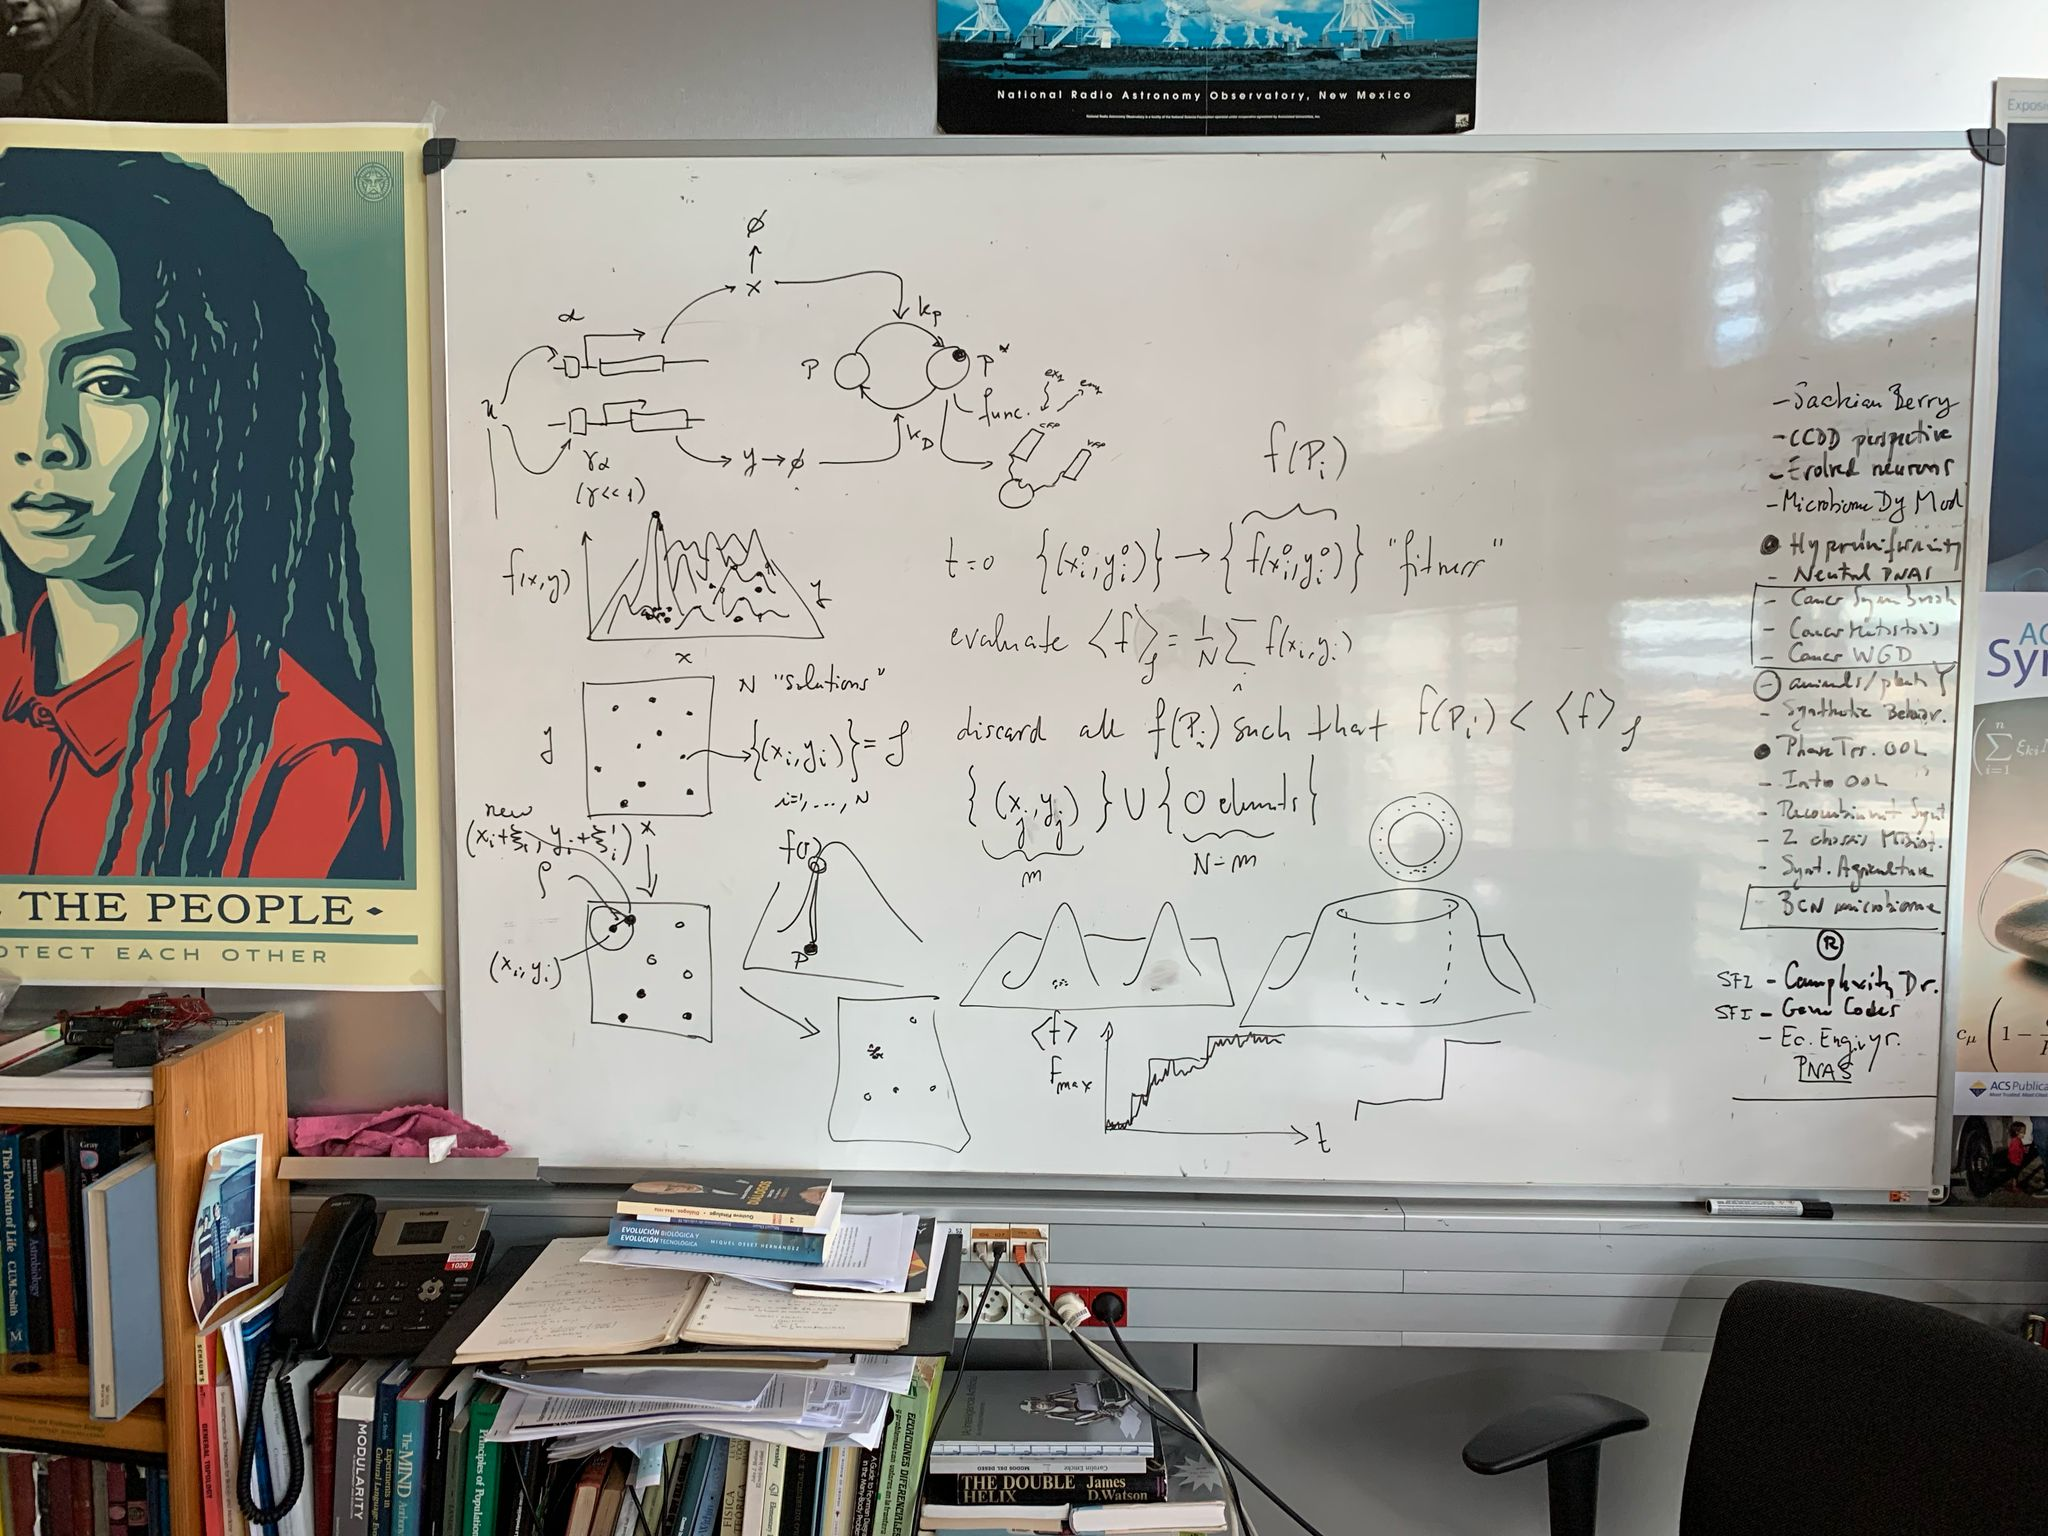

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import cm   # colormap
from matplotlib.ticker import LinearLocator     # for having ticks evenly spaced on the axis
from mpl_toolkits.mplot3d import Axes3D

import evolutionary_programming as ep

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 22,
    'axes.labelsize': 22,
    'xtick.labelsize': 16,
    'ytick.labelsize': 16,
    'legend.fontsize': 20,
    'figure.titlesize': 22
})

In [ ]:
# fixed 1 gaussian peak 3d landscape
def f(x,y):
    return np.exp(-0.1*(x)**2 - 0.1*(y)**2)

In [ ]:
par = {'N': 1000,
       'coord_range': np.array([0,10]),
       'sol_ratio': 1/5,    # eta
       'mutation_radius': 1/20, # mu
       'seed': 12345,
       'n_iter': 200,
       'eps': 0.01}  # epsilon (precision on convergence)

func_par = {'alphas': np.random.uniform(0.,2.,50),
            'offsetsx': np.random.uniform(0.,10.,50),
            'offsetsy':np.random.uniform(0.,10.,50)}

# generate a random 3d landscape by sum of gaussians whose parameters are extracted from a uniform distribution
def f(x,y,func_par:dict):
       alphas, offsetsx, offsetsy = func_par['alphas'], func_par['offsetsx'], func_par['offsetsy']
       f = np.zeros((x.shape))
       for i in range(len(alphas)):
              f += alphas[i] * np.exp(-(x-offsetsx[i])**2-(y-offsetsy[i])**2)     
       return f / np.max(f)

In [ ]:
coord_range = par['coord_range']
N = par['N']
x = np.linspace(coord_range[0],coord_range[1],N)
y = np.linspace(coord_range[0],coord_range[1],N)
X,Y = np.meshgrid(x,y)

fig= plt.figure(figsize=(12,6))

# First subplot (3d view)
ax = fig.add_subplot(1,2,1,projection='3d')
surf = ax.plot_surface(X, Y, f(X,Y,func_par), cmap=cm.coolwarm, linewidth=0, antialiased=False,alpha=0.3)

# Customize the z axis.
ax.zaxis.set_major_locator(LinearLocator(6))
ax.set_zlim(0.0)
# A StrMethodFormatter is used automatically
ax.zaxis.set_major_formatter('{x:.01f}')

# Add axis labels
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x,y)')


# Second subplot (2d view)
ax = fig.add_subplot(1,2,2)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('x')
ax.set_ylabel('y')
levels = np.linspace(0,np.max(f(x,y,func_par)),30)
contour = ax.contourf(X,Y,f(X,Y,func_par),cmap=cm.coolwarm, antialiased=False,levels=levels,alpha=0.8)
ax.scatter(X[np.argmax(f(X,Y,func_par)) // N, np.argmax(f(X,Y,func_par)) % N], 
           Y[np.argmax(f(X,Y,func_par)) // N, np.argmax(f(X,Y,func_par)) % N], 
           marker='x', c='black', label='Global Max')
ax.legend()
# Add a color bar which maps values to colors.
fig.colorbar(contour, shrink=0.7, aspect=7,label='f(x,y)',format='{x:.01f}')

# Move the 3D z-axis to the left side (view adjustment on first subplot)
ax3d = fig.axes[0]
ax3d.view_init(elev=25, azim=120)

plt.savefig('plots/landscape.png')
plt.show()

In [ ]:
mean_ev, max_ev = ep.ep2d(f,par,func_par=func_par,verb=0)

In [ ]:
plt.plot(mean_ev,c='b',label='Mean')
plt.plot(max_ev,c='orange',label='Maximum')
plt.legend()
plt.grid(True)
plt.title('Convergence')
plt.ylabel('Value')
plt.xlabel('Generation')
plt.savefig('plots/convergence.png')
plt.show()

In [ ]:
np.max(f(X,Y,func_par))
mean_ev